In [1]:
from mpi4py import MPI
import coqui

import numpy as np
from scipy.constants import physical_constants
HARTREE_EV = physical_constants['Hartree energy in eV'][0]

import matplotlib.pyplot as plt

# Create CoQui MPI handler and set logging verbosity in the beginning 
coqui_mpi = coqui.MpiHandler()
coqui.set_verbosity(coqui_mpi, output_level=1)

# TODO Introduce IAFT for post-processing 

--------------------------------------------------------------------------
Ignoring value for oob_tcp_if_exclude on worker6063 (10.250.112.0/20: Did not find interface matching this subnet).
(You can safely ignore this message.)
--------------------------------------------------------------------------


# cRPA Screened Interactions with CoQuí

In the previous GW tutorial, we have learned how to perform a GW electronic structure calculation in CoQuí using a compressed Coulomb Hamiltonian and how to post-process the results with maximally localized Wannier functions (MLWFs). Beyond post-processing, **MLWFs also play a central role in CoQuí’s embedding and downfolding functionality**, providing the **bridge** between a full ab initio calculation and a reduced low-energy description. 

In this notebook, we explore one such application: using the constrained random phase approximation (cRPA) to compute the effective, frequency-dependent Coulomb interactions for a low-energy model defined in the Wannier basis. By separating screening processes inside and outside the Hilbert space of the model, cRPA delivers the “rest” screening needed for building an accurate *ab initio* low-energy Hamiltonian. This serves as an entry point to CoQuí’s suite of tools for constructing low-energy models for advanced methods such as DMFT/EDMFT. 

Note that although the U(ω) computed in cRPA is not the same object as the interaction used in GW+EDMFT, in CoQuí both evaluations use the same downfolding interface, accept the same input format (mean-field object, MLWF projectors, Coulomb operator, etc.), and write the same output format (frequency-dependent local U$_{ 
ijkl}$ tensor with the same HDF5 layout and metadata). In the next tutorial, we will revisit the same function call in the GW+EDMFT setting, change only the screening definition, and produces the local interaction consistent with the GW+EDMFT self-consistency loop. 

**What you’ll learn:**
1. How to perform cRPA calculations in CoQuí
2. How to extract a Hubbard–Kanamori parametrization from cRPA results
3. How to visualize the frequency dependence of the screened interactions
4. How window choices and numerical parameters affect the static U(0) and its frequency dependence

## 🔹 cRPA within the generic downfolding workflow in CoQuí

<figure style="text-align: center;">
  <img src="./images/coqui_workflow_crpa.png" alt="cRPA workflow in CoQuí" width="60%">
  <figcaption><em>Figure&nbsp;1:</em> cRPA workflow in CoQuí.</figcaption>
</figure>

As shown in Fig. 1, the cRPA workflow in CoQuí closely mirrors the GW workflow. Both share the same **Phase 1 (Problem Setup)**:
1. Build the mean-field object from DFT outputs  
2. Construct the compressed Coulomb operator (e.g., THC)  
3. Prepare the MLWFs

> 💡 **Tip.** The Coulomb Hamiltonian produced for GW can be reused directly for cRPA.

Once the Coulomb operator has been generated, the cRPA calculation is carried out by calling `downfold_local_coulomb`, which returns the Coulomb matrix elements in the MLWF basis. Importantly, this routine is a **generic two-electron downfolding driver**, and cRPA is simply one of several admissible screening prescriptions. Regardless of which prescription is chosen, the **inputs** (a Green’s function in the Bloch basis, MLWF projectors, and the Coulomb Hamiltonian) and the **outputs** (bare local $V_{ijkl}$ and frequency-dependent local $U_{ijkl}(i\omega_n)$ always have the same structure. 

Translating the workflow in Fig. 1 leads to a practical CoQuí script for cRPA: 
```python
from mpi4py import MPI
import coqui

# Create CoQui MPI handler and set logging verbosity 
coqui_mpi = coqui.MpiHandler()
coqui.set_verbosity(coqui_mpi, output_level=1)

# --- Phase 1: Problem setup ---
# Mean-field (DFT) description of the target system
mf_params = {
    "prefix": "svo", 
    "outdir": "data/qe_inputs/svo/222/out", 
    "nbnd": 40
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

# Construct Coulomb Hamiltonian (in a compressed THC format)
thc_params = {
    "ecut": 40,
    "thresh": 1e-3
}
thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)

# --- Phase 2: Simulation (cRPA) ---
crpa_params = {
    "screen_type": "crpa",
    "input_type": "mf",
    "prefix": "crpa",
    "wannier_file": "data/qe_inputs/svo/222/mlwf/svo.mlwf.h5",
    "beta": 300,
    "wmax": 3.0,
    "iaft_prec": "medium"
}
Vloc, Uloc_t = coqui.downfold_local_coulomb(h_int=thc, params=crpa_params)
```
### 🪜 Step by step in `downfold_local_coulomb`

Regardless the screening prescriptions, `downfold_local_coulomb` takes just two inputs, the interacting Coulomb Hamiltonian (`ThcCoulomb`) and a parameter dictionary `params`. Behind the scene, the function executes a generic **two-electron (2e) downfolding workflow**:

1. **Initialize $G$**:  
   Load the Green's function $G^{\textbf{k}} _{ij}(\tau)$ in the Bloch basis from the CoQuí checkpoint: `{params["prefix"]}.mbpt.h5`. This may be the **mean-field** G$_0$ or an **interacting** G from a prior MBPT run. 
3.  **Screened Coulomb**:  
    1. **Build the polarizability $\Pi(\textbf{q}, i\Omega_{n})$** in the Bloch Hilbert space using the chosen screening prescription: `params["screen_type"]`.  
    3. **Compute the screened interactions $W(\textbf{q}, i\Omega_{n})$**
       $$
       W(\textbf{q}, i\Omega_{n}) = \Big[1 - V(\textbf{q})\Pi(\textbf{q}, i\Omega_{n})\Big]^{-1}V(\textbf{q})
       $$ 
5. **Downfolding**:
   Using the MLWF projectors provided from `params["wannier_file"]`, downfold the bare $V$ and the screened $W$ interactions from the Bloch basis to the local MLWfs subspace, yielding local matrix elements in the MLWF basis.
7. **Return local interactions in the MLWF basis**:  
   - `Vloc`: **bare** local Coulomb integrals $V_{ijkl}$ (frequency-independent)
   - `Wloc`: **screened** local interaction $U_{ijkl}(i\omega_n)$ (**dynamic part only**). 

### ▶️ Running cRPA with `downfold_local_coulomb` 
<figure style="text-align: center;">
  <img src="./images/svo_crpa_cartoon.png" alt="cRPA svo" width="25%">
  <figcaption><em>Figure&nbsp;2:</em> cRPA of V \(t_{2g}\) orbitals.</figcaption>
</figure>

When `params["screen_type"]` is set to `"crpa"`, CoQuí computes the local screened interactions using the **rest** polarizability $\Pi^{r}$ in the Bloch basis:  
$$
\Pi^{r}(\textbf{q}, i\Omega_{n}) = \Pi_{\mathrm{RPA}}(\textbf{q}, i\Omega_{n}) - \Pi^{d}_{\mathrm{RPA}}(\textbf{q}, i\Omega_{n})
$$
where $\Pi^d$ collects screening processes entirely within the MLWF target subspace (red in Fig. 2), and $\Pi^r$ encodes the remaining screening channels (blue in Fig. 2).

### 🎬 Input Green's Function $G^{\textbf{k}} _{ij}(\tau)$
The function `downfold_local_coulomb` accesses the input Green’s function $G_{ij}^{\mathbf k}(\tau)$ from the given CoQuí checkpoint file. Depending on the intended use, users has the flexibility to specify the source of $G_{ij}^{\mathbf k}(\tau)$ via `params["input_type"]`:
- `"mf"` — use the **mean-field** Green’s function $G_0$.
- `"scf"` — use an **interacting** Green’s function $G$ from a prior MBPT run.

### 🔹 Key arguments in `params` for `downfold_local_coulomb`:
  - `screen_type`: "crpa" (remove target-space transitions) or "rpa" (all screening).
  - `prefix`: Prefix for CoQuí checkpoint file where input $G^{\textbf{k}} _{ij}(\tau)$ is read. 
  - `input_type`: "mf" (use mean-field inputs) or "scf" (interacting $G$ from a prior MBPT run)
  - `wannier_file`: path to CoQuí MLWF HDF5
  - `output_in_tau`: Return the dynamic screened interaction on the imaginary-time axis (if `True`) or on the Matsubara frequency axis (if `False`).

### 🖐️ Hands-on 0: Building the Coulomb Hamiltonian for cRPA
Run the **Phase 1** block of the cRPA script above to construct the THC Coulomb Hamiltonian. 
The object will be **reused** in later cRPA runs. 

After running, check the log to confirm:  
- the mean-field object was created from the QE outputs, and  
- the THC Coulomb Hamiltonian was successfully built (with your chosen cutoff and threshold).  

In [2]:
# --- Phase 1: Problem setup ---
# Mean-field (DFT) description of the target system
mf_params = {
    "prefix": "svo", 
    "outdir": "data/qe_inputs/svo/222/out", 
    "nbnd": 35
}
mf = coqui.make_mf(coqui_mpi, params=mf_params, mf_type="qe")

# Construct Coulomb Hamiltonian (in a compressed THC format)
thc_params = {
    "ecut": 40,
    "thresh": 1e-3
}
thc = coqui.make_thc_coulomb(mf=mf, params=thc_params)

  Quantum ESPRESSO reader
  -----------------------
  Number of spins                = 1
  Number of polarizations        = 1
  Number of bands                = 35
  Monkhorst-Pack mesh            = (2,2,2)
  K-points                       = 8 total, 4 in the IBZ
  Number of electrons            = 41.0
  Electron density energy cutoff = 360.000 a.u. | FFT mesh = (45,45,45)
  Wavefunction energy cutoff     = 51.704 a.u. | FFT mesh = (23,23,23), Number of PWs = 6859


╔═╗╔═╗╔═╗ ╦ ╦╦  ╔╦╗┬ ┬┌─┐╔═╗┌─┐┬ ┬┬  ┌─┐┌┬┐┌┐ 
║  ║ ║║═╬╗║ ║║   ║ ├─┤│  ║  │ ││ ││  │ ││││├┴┐
╚═╝╚═╝╚═╝╚╚═╝╩   ╩ ┴ ┴└─┘╚═╝└─┘└─┘┴─┘└─┘┴ ┴└─┘

  Algorithm                       = ISDF
  THC integrals access            = incore
  Found precomputed THC integrals = false
  --> CoQuí will compute THC integrals.

  ERI::thc Computation Details
  ----------------------------
  Energy cutoff                = 40.0 a.u. | FFT mesh = (23,23,23), Number of PWs = 4625
  Threshold                    = 0.001

*****************************

### 🖐️ Hands-on 1: Running cRPA and Inspecting the Log

Now run the Phase 2 of the cRPA script provided above. CoQuí will generate a log file summarizing key parts of the calculation.  
Use the output below as a guide, and Take a few minutes to answer these questions on the following questions while inspecting your own log:  

1. **Target subspace (MLWF projectors)**  
   - How many local orbitals are included in the impurity subspace?
   - Does this match the MLWF definition of your target subspace?

2. **Input Green’s function & screening type**  
   - From which checkpoint is the Green’s function read (mean-field or MBPT)?
   - How does the log confirm that the screening is performed in cRPA?

3. **Bare vs. screened interactions**  
   - Compare the orbital-averaged bare interactions (intra-/inter-orbital, Hund’s couplings) to the screened ones.  
   - By how much are the interactions reduced? Why is this reduction important for constructing realistic low-energy models?  

4. **Imaginary-part warnings**  
   - The log may display warnings about the imaginary parts of $V$ or $W$.  
   - Why do you think these are checked, and under what conditions would you expect them to vanish?  

In [3]:
# --- Phase 2: Simulation (cRPA) ---
crpa_params = {
    "screen_type": "crpa",
    "input_type": "mf",
    "prefix": "crpa",
    "wannier_file": "data/qe_inputs/svo/222/mlwf/svo.mlwf.h5",
    "beta": 300,
    "wmax": 3.0,
    "iaft_prec": "medium"
}
Vloc, Uloc_t = coqui.downfold_local_coulomb(h_int=thc, params=crpa_params)


╔══════════════════════════════════════════════════════════╗
║ [ WARNING ]                                              ║
║ Input type is set to "mf", while a CoQuí checkpoint      ║
║ HDF5 with the same prefix has been detected. CoQuí will  ║
║ overwrite the old checkpoint. Considering moving the old ║
║ HDF5 or changing CoQuí prefix next time.                 ║
╚══════════════════════════════════════════════════════════╝

  Projector Information
  ---------------------
  Number of impurities                      = 1
  Number of local orbitals per impurity     = 3
  Range of primary orbitals for local basis = [20, 23)

  Mesh details on the imaginary axis
  ----------------------------------
  Intermediate Representation
  Beta                   = 300.0 a.u.
  Frequency cutoff       = 3.3333333333333335 a.u.
  Lambda                 = 1000.0
  Precision              = 1e-10
  nt_f, nt_b, nw_f, nw_b = 52, 52, 52, 53


╔═╗╔═╗╔═╗ ╦ ╦╦  ┌┬┐┬ ┬┌─┐   ┌─┐  ┌┬┐┌─┐┬ ┬┌┐┌┌���┐┌─┐┬  ┌┬┐
║  ║ ║║

## 🔧 Technical aside — Imaginary‑axis meshes & Fourier transforms

In many CoQuí workflows we need to move between **imaginary time τ** and **Matsubara frequencies i⍵$_n$**. Not only in electronic structure solvers, this is also essential for analyzing and plotting the resulting correlation functions. In CoQuí, all mesh construction and Fourier transforms on the imaginary axis are handled by the `IAFT` class (both in Python and C++). This class provides a unified way to access IR bosonic/fermionic mesh points, and perform τ↔i$\omega_{n}$ transforms. It is particularly useful for post-processing correlation functions generated by CoQuí and for DMFT/EDMFT workflows when exchanging data with external libraries that do not use the same mesh. 

In this tutorial, the `IAFT` class will be used to Fourier transform the imaginary-time screened interactions onto the Matsubara axis, allowing us to analyze their frequency dependence and extract the static limit. A standard usage looks like 
```python
from coqui.utils.imag_axes_ft import IAFT

# --- Initialization ---
ft_kernel = IAFT(beta, wmax, prec)

# --- Mesh points ---
# imaginary-time grid
tau_mesh_fermion, tau_mesh_boson = ft_kernel.tau_mesh_f, ft_kernel.tau_mesh_b  
# Matsubara frequency indices 
wn_mesh_fermion, wn_mesh_boson = ft_kernel.wn_mesh(stats='f'), ft_kernel.wn_mesh(stats='b')

# --- Fourier transform ---
W_iw  = ft_kernel.tau_to_iw(W_tau, stats='b')   # τ → iν
W_tau = ft_kernel.iw_to_tau(W_iw, stats='b')    # iν → τ
```
where the `IAFT` objecet is constructed via: 
```python
coqui.utils.imag_axes_ft.IAFT(beta: float, wmax: float, prec: str/float)
```
where `beta`, `wmax` and `prec` are exactly the same quantities in other CoQuí routines. 


### 📘 More functions?
Use Python’s help system to explore IAFT’s doc strings:
```python
help(IAFT)           # class-level doc
help(iaft.tau_to_iw) # method-level doc
```

### 🖐️ Hands-on 2: Plotting the frequency dependence of the screened interaction

The output of `downfold_local_coulomb` gives the dynamic screened interaction on the **imaginary-time axis**: $U_{ijkl}(\tau)$. The goal of this hands-on is to learn how to Fourier transform $U(\tau)$ to the bosonic Matsubara frequency axis $U(i\omega_{n})$ and visualize how screening weakens as $|\omega_n|$ increases. 

🪜 **Your task:**
1. Initialize an `IAFT` object with the same `beta`, `wmax`, and `prec` as in your cRPA calculation
2. Fourier transform the dynamic screened interaction from τ to i⍵$_{n}$ using
```python
   Uloc_iw = IAFT.tau_to_w_phsym(Uloc_t, stats='b')
```
4. Select representative matrix elements, such as the diagonal $U_{iiii}$ and one inter-orbital $U_{ijij}$
5. Plot **Re**$U(i\omega_n)$ vs $\omega_n$ 
6. Read off the **static limit** $U(i\omega_{n}=0)$ and compare with the values reported in the log file
7. (Optional) Overlay curves from cRPA and RPA runs to compare their frequency dependence.

💡 **Hints:**
- Use the bosonic Matsubara mesh: `wn_mesh_b = iaft.wn_mesh(stats='b')`.
- Don't forget to include the **bare interactions $V$**, which correspond to the infinite-frequency limit of $U(i\omega_{n})$. 

Mesh details on the imaginary axis
----------------------------------
Intermediate Representation
precision = 1e-10
beta = 300
frequency cutoff = 3.3333333333333335
lambda = 1000
nt_f, nw_f = 52, 52
nt_b, nw_b = 52, 53



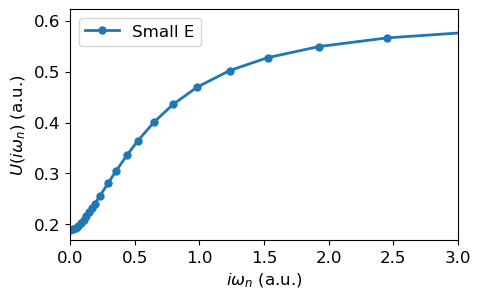

In [4]:
from coqui.utils.imag_axes_ft import IAFT

ir_kernel = IAFT(beta=300, wmax=3.0, prec="medium")
Uloc_iw = ir_kernel.tau_to_w_phsym(Uloc_t, stats='b')

iw_mesh = ir_kernel.wn_mesh(stats='b', positive_only=True) * np.pi / 300.0

fig, ax = plt.subplots(1, figsize=(5,3))
ax.plot(iw_mesh, (Vloc[0,0,0,0]+Uloc_iw[:,0,0,0,0]).real, 
        linewidth=2, marker='o', markersize=5, label='Small E')
#ax.plot(iw_mesh, (Vloc2[0,0,0,0]+Uloc2[:,0,0,0,0]).real, 
#        linewidth=2, marker='s', markersize=5, label='Large E')
ax.set_xlim(0,3)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlabel('$i\omega_{n}$ (a.u.)', fontsize=12)
ax.set_ylabel('$U(i\omega_{n})$ (a.u.)', fontsize=12)
ax.legend(fontsize=12)
plt.show()

### 🖐️ Hands-on 3: Extracting the Hubbard–Kanamori Parameters

The local Coulomb interaction returned by `downfold_local_coulomb` is a full **four-index tensor** $U_{ijkl}(i\omega_n)$ in the Wannier basis. For many applications (e.g. DMFT), this tensor is reduced to the **Hubbard–Kanamori parametrization**: intra-orbital $U$, inter-orbital $U'$, and Hund’s couplings $J$ (spin-flip and pair-hopping).

🪜 Your task:  
1. Construct the static interactions tensor $U_{ijkl}$ from the returned bare interaction $V$ and screened interaction $W(i\Omega_{n})$ at **static limit** $\omega_n=0$ 
2. From this tensor, extract the Hubbard-Kanamori parametrizations: $U$, $U'$, and $J$ for same spins and opposite spins 
3. Check whether the spin-flip and pair-hopping terms are identical. Should they always be the same? 
4. Compare your results with the orbital-averaged summary printed in the log.  

In [5]:
# Your task: Write a function to return orbital-average parametrization of the Hubbard Kanamori model
def orb_avg_coulomb(V_abcd):
    norb = V_abcd.shape[0]

    U = 0
    for i in range(norb):
        U += V_abcd[i,i,i,i]
    U /= norb

    Up = 0
    for i in range(norb):
        for j in range(i+1,norb):
            if i!=j:
                Up += V_abcd[i,i,j,j]
    Up /= (norb * (norb-1) ) / 2

    J_pair = 0
    for i in range(norb):
        for j in range(i+1,norb):
            if i!=j:
                J_pair += V_abcd[i,j,i,j]
    J_pair /= (norb * (norb-1) ) / 2

    J_spin = 0
    for i in range(norb):
        for j in range(i+1,norb):
            if i!=j:
                J_spin += V_abcd[i,j,j,i]
    J_spin /= (norb * (norb-1) ) / 2

    return U, Up, J_pair, J_spin

In [10]:
V, Vp, J_pair, J_spin = orb_avg_coulomb(Vloc.real * HARTREE_EV)
U, Up, J_pair_scr, J_spin_scr = orb_avg_coulomb(Uloc_iw[0].real * HARTREE_EV)
print("Small window")
print("-"*13)
print("Bare Interactions")
print(f"  - Intra-orbital: {V}")
print(f"  - Inter-orbital: {Vp}")
print(f"  - Pair hopping: {J_pair}")
print(f"  - Spin flip:    {J_spin}")
print("Screened Interactions")
print(f"  - Intra-orbital: {V+U}")
print(f"  - Inter-orbital: {Vp+Up}")
print(f"  - Pair hopping: {J_pair+J_pair_scr}")
print(f"  - Spin flip:    {J_spin+J_spin_scr}\n")

Small window
-------------
Bare Interactions
  - Intra-orbital: 16.37903968056372
  - Inter-orbital: 15.017597158957832
  - Pair hopping: 0.6469214401353875
  - Spin flip:    0.6469214401353875
Screened Interactions
  - Intra-orbital: 5.150519357062345
  - Inter-orbital: 4.02230603356829
  - Pair hopping: 0.5402728207248652
  - Spin flip:    0.5402728207248652



### 🖐️ Hands-on 4: Effect of the Energy Window in cRPA

In cRPA, the definition of the low-energy subspace depends on the **energy window** chosen when constructing the MLWF projectors. Enlarging this window includes more bands in the Wannierization, which makes the MLWFs more localized. The stronger locality therefore lead to **larger Coulomb interactions**. 

🪜 **Your task:**  
1. Re-run the cRPA calculation with a **larger Wannier energy window** (include more bands in the Wannierization step).  
2. Extract the static Hubbard–Kanamori parameters (\(U, U', J\)) from the output.  
3. Compare these values with those from the smaller-window calculation.  
4. Discuss:  
   - Do you see the expected increase in Coulomb interactions?  
   - Why does stronger localization of MLWFs lead to larger effective interactions?

In [8]:
# --- Phase 2: Simulation (cRPA) ---
crpa_params = {
    "screen_type": "crpa",
    "input_type": "mf",
    "prefix": "crpa",
    "wannier_file": "data/qe_inputs/svo/222/mlwf_dp/svo.mlwf.h5",
    "beta": 300,
    "wmax": 3.0,
    "iaft_prec": "medium"
}
Vloc_dp, Uloc_dp_t = coqui.downfold_local_coulomb(h_int=thc, params=crpa_params)
Vloc2, Uloc2_t = Vloc_dp[:3, :3, :3, :3], Uloc_dp_t[:, :3, :3, :3, :3]
Uloc2_iw = ir_kernel.tau_to_w_phsym(Uloc2_t, stats='b')


╔══════════════════════════════════════════════════════════╗
║ [ WARNING ]                                              ║
║ Input type is set to "mf", while a CoQuí checkpoint      ║
║ HDF5 with the same prefix has been detected. CoQuí will  ║
║ overwrite the old checkpoint. Considering moving the old ║
║ HDF5 or changing CoQuí prefix next time.                 ║
╚══════════════════════════════════════════════════════════╝

  Projector Information
  ---------------------
  Number of impurities                      = 1
  Number of local orbitals per impurity     = 14
  Range of primary orbitals for local basis = [11, 30)

  Mesh details on the imaginary axis
  ----------------------------------
  Intermediate Representation
  Beta                   = 300.0 a.u.
  Frequency cutoff       = 3.3333333333333335 a.u.
  Lambda                 = 1000.0
  Precision              = 1e-10
  nt_f, nt_b, nw_f, nw_b = 52, 52, 52, 53


╔═╗╔═╗╔═╗ ╦ ╦╦  ┌┬┐��� ┬┌─┐   ┌─┐  ┌┬┐┌─┐┬ ┬┌┐┌┌─┐┌─┐┬  ┌┬┐
║  ║ ║

In [11]:
V, Vp, J_pair, J_spin = orb_avg_coulomb(Vloc2.real * HARTREE_EV)
U, Up, J_pair_scr, J_spin_scr = orb_avg_coulomb(Uloc2_iw[0].real * HARTREE_EV)
print("Large window")
print("-"*13)
print("Bare Interactions")
print(f"  - Intra-orbital: {V}")
print(f"  - Inter-orbital: {Vp}")
print(f"  - Pair hopping: {J_pair}")
print(f"  - Spin flip:    {J_spin}")
print("Screened Interactions")
print(f"  - Intra-orbital: {V+U}")
print(f"  - Inter-orbital: {Vp+Up}")
print(f"  - Pair hopping: {J_pair+J_pair_scr}")
print(f"  - Spin flip:    {J_spin+J_spin_scr}")

Large window
-------------
Bare Interactions
  - Intra-orbital: 19.35592351391548
  - Inter-orbital: 17.683828379760346
  - Pair hopping: 0.8442838328198765
  - Spin flip:    0.8442838328198765
Screened Interactions
  - Intra-orbital: 14.043793137415058
  - Inter-orbital: 12.491451695473959
  - Pair hopping: 0.7909294646792444
  - Spin flip:    0.7909294646792444


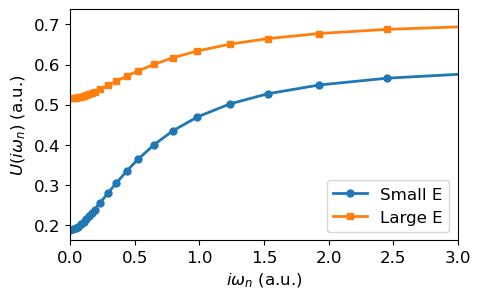

In [12]:
fig, ax = plt.subplots(1, figsize=(5,3))
ax.plot(iw_mesh, (Vloc[0,0,0,0]+Uloc_iw[:,0,0,0,0]).real, 
        linewidth=2, marker='o', markersize=5, label='Small E')
ax.plot(iw_mesh, (Vloc2[0,0,0,0]+Uloc2_iw[:,0,0,0,0]).real, 
        linewidth=2, marker='s', markersize=5, label='Large E')
ax.set_xlim(0,3)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.set_xlabel('$i\omega_{n}$ (a.u.)', fontsize=12)
ax.set_ylabel('$U(i\omega_{n})$ (a.u.)', fontsize=12)
ax.legend(fontsize=12)
plt.show()